In [49]:
import pandas as pd
import seaborn as sns
import yaml
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.stats import chi2_contingency

In [12]:
with open("../config.yaml", "r") as file:
    config = yaml.safe_load(file)

In [ ]:
clients_test = pd.read_csv(config["output_data"]["file4"])
clients_test

In [14]:
clients_test.columns

Index(['client_id', 'clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age', 'gendr',
       'num_accts', 'bal', 'calls_6_mnth', 'logons_6_mnth', 'variation'],
      dtype='str')

In [15]:
# Filter test group by gender
female_clients_test = clients_test[clients_test['gendr'] == 'F']

# Quick check 

print(f"Test Female: {len(female_clients_test)}")


Test Female: 8716


In [16]:
male_clients_test = clients_test[clients_test['gendr'] == 'M']
male_clients_test
print(f"Test male: {len(male_clients_test)}")

Test male: 8977


In [17]:
unknown_clients_test = clients_test[clients_test['gendr'] == 'U']
unknown_clients_test
print(f"Test unknown: {len(unknown_clients_test)}")

Test unknown: 9266


Computing the difference between male and female clients does not make sence when the group of clients with unknown gender is the biggest group. We decided to discard the gender hypothesis and go with tenure years instead.

NEW Null Hypothesis:
The average client tenure(how long they've been with Vanguard) of users engaging with the new process is the same as the average client tenure of users engaging with the old process.

Alternative Hypothesis:
The average client tenure (how long they've been with Vanguard) of users engaging with the new process is different from the average client tenure of users engaging with the old process. If so what's the difference.

Make sure to consider:

the significance level,
p-value,
the statistical test prerequisites,
other relevant statistical measures in your analysis.

In [18]:
tenure_control = pd.read_csv(config["output_data"]["file3"])
tenure_control

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,variation
0,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0,control
1,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0,control
2,3727881,5.0,71.0,30.5,U,2.0,23915.60,0.0,3.0,control
3,272934,5.0,66.0,58.5,U,2.0,27021.42,2.0,5.0,control
4,285619,30.0,369.0,67.5,M,2.0,299388.72,3.0,6.0,control
...,...,...,...,...,...,...,...,...,...,...
23522,6662941,7.0,84.0,36.0,F,2.0,83101.84,4.0,7.0,control
23523,2787512,23.0,283.0,48.0,F,3.0,123618.60,1.0,4.0,control
23524,9932367,23.0,280.0,57.0,F,2.0,94466.55,6.0,9.0,control
23525,4079649,23.0,276.0,62.5,M,3.0,57575.28,4.0,7.0,control


In [19]:
tenure_test = clients_test
tenure_test

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,variation
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0,test
1,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0,test
2,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0,test
3,388801,30.0,361.0,57.5,M,5.0,522498.72,1.0,4.0,test
4,8198645,15.0,189.0,54.5,F,2.0,382303.83,6.0,9.0,test
...,...,...,...,...,...,...,...,...,...,...
26956,501496,23.0,281.0,35.0,F,2.0,32529.34,0.0,3.0,test
26957,1780858,21.0,262.0,68.5,M,3.0,372100.59,6.0,9.0,test
26958,5826160,20.0,249.0,56.5,F,2.0,44837.16,2.0,5.0,test
26959,8739285,19.0,229.0,69.5,F,2.0,44994.24,1.0,4.0,test


In [20]:
tenure_test.columns

Index(['client_id', 'clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age', 'gendr',
       'num_accts', 'bal', 'calls_6_mnth', 'logons_6_mnth', 'variation'],
      dtype='str')

In [21]:
clients_test['clnt_tenure_yr'].unique()

array([ 6.,  5., 16., 30., 15.,  4.,  3., 11.,  8., 12.,  7., 19., 18.,
       23., 21.,  9., 14., 27., 24., 28., 13., 20., 10., 29., 17., 22.,
       25., 26., 32., 33., 35.,  2., 38., 31., 34., 36., 51., 47., 37.,
       40., 55., 48., 43., 49., 39., 42., 50., 46., 44.])

In [22]:
clients_test['logons_6_mnth'].unique()

array([9., 6., 4., 8., 7., 5., 3.])

In [23]:
# Check tenure in both groups
print("TEST GROUP:")
print(tenure_test['clnt_tenure_yr'].describe())

print("\nCONTROL GROUP:")
print(tenure_control['clnt_tenure_yr'].describe())

TEST GROUP:
count    26961.000000
mean        11.982901
std          6.844947
min          2.000000
25%          6.000000
50%         11.000000
75%         15.000000
max         55.000000
Name: clnt_tenure_yr, dtype: float64

CONTROL GROUP:
count    23527.000000
mean        12.087686
std          6.877531
min          2.000000
25%          6.000000
50%         11.000000
75%         16.000000
max         55.000000
Name: clnt_tenure_yr, dtype: float64


Independence is logically confirmed by asking:
Are these different people/entities?✅ Yes, different clients
Could one observation influence another?❌ No, clients are independent
Is the same person in both groups?❌ No, test and control are separate clients

In [26]:
from scipy import stats

# Normality test for both groups
stat_test, p_test = stats.normaltest(tenure_test['clnt_tenure_yr'])
stat_control, p_control = stats.normaltest(tenure_control['clnt_tenure_yr'])

print(f"Test group normality p-value: {p_test:.10f}")
print(f"Control group normality p-value: {p_control:.10f}")

Test group normality p-value: 0.0000000000
Control group normality p-value: 0.0000000000


For both groups p-value is 0 so not normally ditributed. This is common in bigger datasets. 
But we can use the Central Limit Theorem which says:

"With a large enough sample size (usually >30), the distribution of the mean behaves normally — regardless of the original distribution!"

Equal variances:          Unequal variances:
Test:    ████████         Test:    ██
Control: ████████         Control: ████████████████

In [27]:
# Levene's test for equal variances
stat, p_levene = stats.levene(tenure_test['clnt_tenure_yr'], tenure_control['clnt_tenure_yr'])

print(f"Levene's test p-value: {p_levene:.4f}")

Levene's test p-value: 0.3702


p-value = 0.3702 which is > 0.05 → variances are equal ✅
So our checklist is now:

✅ Independence — logically confirmed
✅ Normality — CLT saves us
✅ Equal variances — confirmed by Levene's test

let's run a T-test: "Are the averages of two groups significantly different, or is it just random chance?"
set the significance level: 0.05 normal 

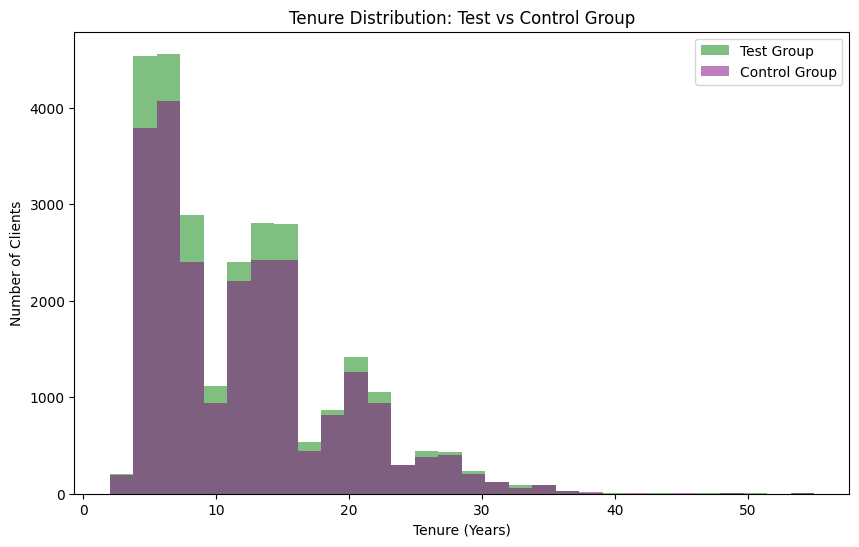

In [63]:
plt.figure(figsize=(10, 6))
plt.hist(tenure_test['clnt_tenure_yr'], bins=30, alpha=0.5, label='Test Group', color='green')
plt.hist(tenure_control['clnt_tenure_yr'], bins=30, alpha=0.5, label='Control Group', color='purple')
plt.xlabel('Tenure (Years)')
plt.ylabel('Number of Clients')
plt.title('Tenure Distribution: Test vs Control Group')
plt.legend()
plt.show()

In [28]:
# T-test with equal variances
stat, p_ttest = stats.ttest_ind(
    tenure_test['clnt_tenure_yr'], 
    tenure_control['clnt_tenure_yr'],
    equal_var=True
)

print(f"T-statistic: {stat:.4f}")
print(f"P-value: {p_ttest:.4f}")

T-statistic: -1.7121
P-value: 0.0869


P-value (0.0869) > α (0.05) → Fail to reject H₀
"The difference in average tenure between test and control groups is not statistically significant — it's likely just random chance!"

In [ ]:
Follow up Hypothesis:
H₀: The completion rate of the new process is the same as the old process
H₁: The completion rate of the new process is different from the old process

In [29]:
df_web = pd.read_csv(config["output_data"]["file6"])
df_web

,client_id,visitor_id,visit_id,process_step,date_time
0,169,201385055_71273495308,749567106_99161211863_557568,start,2017-04-12 20:19:36
1,169,201385055_71273495308,749567106_99161211863_557568,step_1,2017-04-12 20:19:45
2,169,201385055_71273495308,749567106_99161211863_557568,step_2,2017-04-12 20:20:31
3,169,201385055_71273495308,749567106_99161211863_557568,step_3,2017-04-12 20:22:05
4,169,201385055_71273495308,749567106_99161211863_557568,confirm,2017-04-12 20:23:09
...,...,...,...,...,...
755400,9999875,738878760_1556639849,931268933_219402947_599432,step_1,2017-06-01 22:40:08
755401,9999875,738878760_1556639849,931268933_219402947_599432,step_1,2017-06-01 22:41:28
755402,9999875,738878760_1556639849,931268933_219402947_599432,step_2,2017-06-01 22:41:47
755403,9999875,738878760_1556639849,931268933_219402947_599432,step_3,2017-06-01 22:44:58


check for errors in the process
1. First check the overall data quality in df_web
2. Then split and compare errors between groups

In [30]:
# Get all client_ids that reached confirm
confirmed_clients = df_web[df_web['process_step'] == 'confirm']['client_id'].unique()

# For each confirmed client, check if they have all steps
steps = ['start', 'step_1', 'step_2', 'step_3', 'confirm']

# Check which confirmed clients have all steps
complete_journeys = df_web[df_web['client_id'].isin(confirmed_clients)].groupby('client_id')['process_step'].apply(set)

# Check if all steps are present
complete_journeys = complete_journeys.apply(lambda x: all(step in x for step in steps))

print(f"Clients who confirmed WITH all steps: {complete_journeys.sum()}")
print(f"Clients who confirmed WITHOUT all steps: {(~complete_journeys).sum()}")

Clients who confirmed WITH all steps: 79733
Clients who confirmed WITHOUT all steps: 1412


There are 1,412 clients who somehow reached "confirm" without completing all steps — that's about 1.7% of confirmed clients.
These are likely data errors 🐛. A few possible explanations:

Technical glitches in the tracking system
Clients who skipped steps somehow
Data collection errors

But it could be more serious, noone should be able to reach confirm whitout for example logging in.

Are these errors evenly spread between test and control groups, or are there more errors in one group?

In [31]:
# Get the problematic client_ids
incomplete_confirmers = complete_journeys[~complete_journeys].index

# Check which group they belong to
# First what are the names of your test and control dataframes?
# And do they have a 'client_id' column?

test_errors = incomplete_confirmers.isin(tenure_test['client_id']).sum()
control_errors = incomplete_confirmers.isin(tenure_control['client_id']).sum()

print(f"Incomplete confirmers in TEST group: {test_errors}")
print(f"Incomplete confirmers in CONTROL group: {control_errors}")

Incomplete confirmers in TEST group: 349
Incomplete confirmers in CONTROL group: 228


Test group:
Incomplete confirmers: 349
Total clients: 26.961
Error rate: 1.29%

Control group:
Incomplete confirmers: 228
Total clients: 23.527
Error rate: 0.97%

The error rates are very similar (1.29% vs 0.97%) — both are tiny!
However there are 575 unaccounted errors (349 + 228 = 577, but total was 1,412) — meaning some incomplete confirmers don't belong to either group.

What to do with these errors?
I removed them from the analysis because:

- They represent bad/incomplete data
- The error rate is similar in both groups so removing them won't bias your results
- They could skew your completion rate calculations

In [38]:
# Remove incomplete confirmers from df_web
error_free_df_web = df_web[~df_web['client_id'].isin(incomplete_confirmers)]

print(f"Original df_web rows: {len(df_web)}")
print(f"Error_free_df_web rows: {len(error_free_df_web)}")

Original df_web rows: 755405
Error_free_df_web rows: 749101


In [40]:
# Remove incomplete confirmers from df_web
error_free_df_web = df_web[~df_web['client_id'].isin(incomplete_confirmers)]

# Only keep clients in test or control group
all_clients = pd.concat([tenure_test[['client_id']], tenure_control[['client_id']]])
error_free_df_web = error_free_df_web[error_free_df_web['client_id'].isin(all_clients['client_id'])]

print(f"Original df_web rows: {len(df_web)}")
print(f"Error_free_df_web rows: {len(error_free_df_web)}")

Original df_web rows: 755405
Error_free_df_web rows: 318706


Error_free_df_web rows: 749.101
Error free and part of test or control group : 318.706

This means a lot of web activity in df_web belongs to clients that are not in your test or control group at all.

In [ ]:
#save web_df without errors and only test or control group
#error_free_df_web.to_csv('error_free_df_web.csv', index=False)

In [42]:
# Find clients who completed the process (reached 'confirm')
completed = error_free_df_web[error_free_df_web['process_step'] == 'confirm']['client_id'].unique()

# Check completion for test and control groups
test_completed = tenure_test['client_id'].isin(completed).sum()
test_not_completed = len(tenure_test) - test_completed

control_completed = tenure_control['client_id'].isin(completed).sum()
control_not_completed = len(tenure_control) - control_completed

# Build contingency table
contingency_table = pd.DataFrame({
    'Completed': [test_completed, control_completed],
    'Not Completed': [test_not_completed, control_not_completed]
}, index=['Test', 'Control'])

print(contingency_table)

         Completed  Not Completed
Test         18333           8628
Control      15201           8326


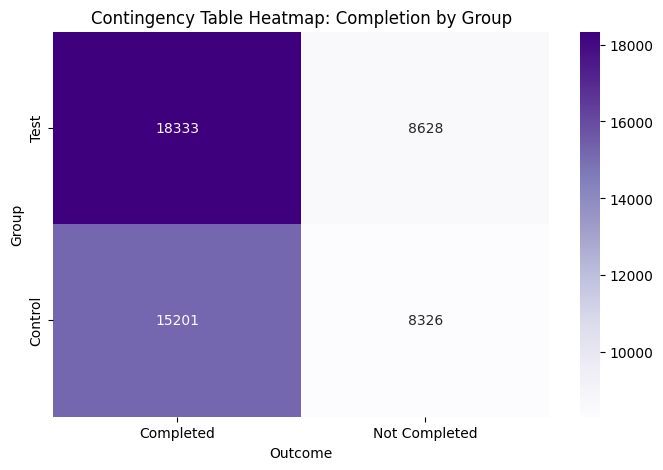

In [71]:
plt.figure(figsize=(8, 5))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='Purples')
plt.title('Contingency Table Heatmap: Completion by Group')
plt.ylabel('Group')
plt.xlabel('Outcome')
plt.show()

In [47]:
test_percentage_completed = (18333 /26961)*100
control_percentage_completed = (15201 /23527)*100
print(test_percentage_completed)
print(control_percentage_completed)

67.99821965060643
64.61087261444298


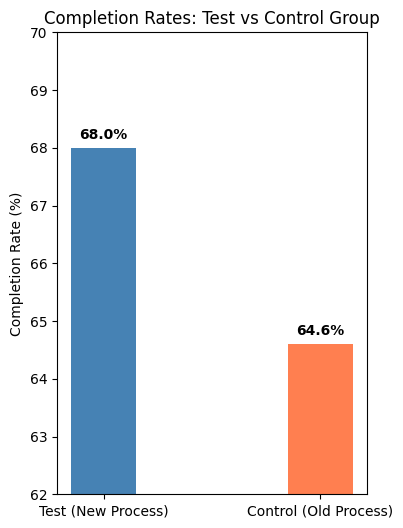

In [54]:
groups = ['Test (New Process)', 'Control (Old Process)']
completion_rates = [68.0, 64.6]

plt.figure(figsize=(4, 6))
bars = plt.bar(groups, completion_rates, color=['steelblue', 'coral'], width=0.3)
plt.ylabel('Completion Rate (%)')
plt.title('Completion Rates: Test vs Control Group')
plt.ylim(62, 70)  # zoom in to make difference visible

# Add percentage labels on top of bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.1, 
             f'{bar.get_height()}%', 
             ha='center', va='bottom', fontweight='bold')

plt.show()

In [ ]:
# Run Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")

Chi-square statistic: 64.4810
P-value: 0.0000
Degrees of freedom: 1


The Control group has a 64.6% completion rate
The Test group has a 68% completion rate
difference is +3.4%

Chi-square (64.48) → very far from 0 → the difference between groups is very large
P-value (0.0000) → basically 0% chance this difference is random
Degrees of freedom (1) → we have 2 groups and 2 outcomes (completed/not) → always 1 in a 2x2 table

"The new process significantly improves completion rates — this is NOT random chance!"

In [72]:
# Create tenure buckets in both groups
bins = [0, 5, 15, 30, 55]
labels = ['New (0-5yr)', 'Mid (6-15yr)', 'Loyal (16-30yr)', 'Veteran (30+yr)']

tenure_test['tenure_group'] = pd.cut(tenure_test['clnt_tenure_yr'], bins=bins, labels=labels)
tenure_control['tenure_group'] = pd.cut(tenure_control['clnt_tenure_yr'], bins=bins, labels=labels)

# Add completed column to both groups
tenure_test['completed'] = tenure_test['client_id'].isin(completed).astype(int)
tenure_control['completed'] = tenure_control['client_id'].isin(completed).astype(int)

# Calculate completion rate per tenure group
test_rates = tenure_test.groupby('tenure_group')['completed'].mean() * 100
control_rates = tenure_control.groupby('tenure_group')['completed'].mean() * 100

print("TEST completion rates by tenure group:")
print(test_rates)
print("\nCONTROL completion rates by tenure group:")
print(control_rates)

TEST completion rates by tenure group:
tenure_group
New (0-5yr)        69.407548
Mid (6-15yr)       68.170700
Loyal (16-30yr)    66.687817
Veteran (30+yr)    65.079365
Name: completed, dtype: float64

CONTROL completion rates by tenure group:
tenure_group
New (0-5yr)        65.429002
Mid (6-15yr)       64.705882
Loyal (16-30yr)    63.678161
Veteran (30+yr)    66.765579
Name: completed, dtype: float64


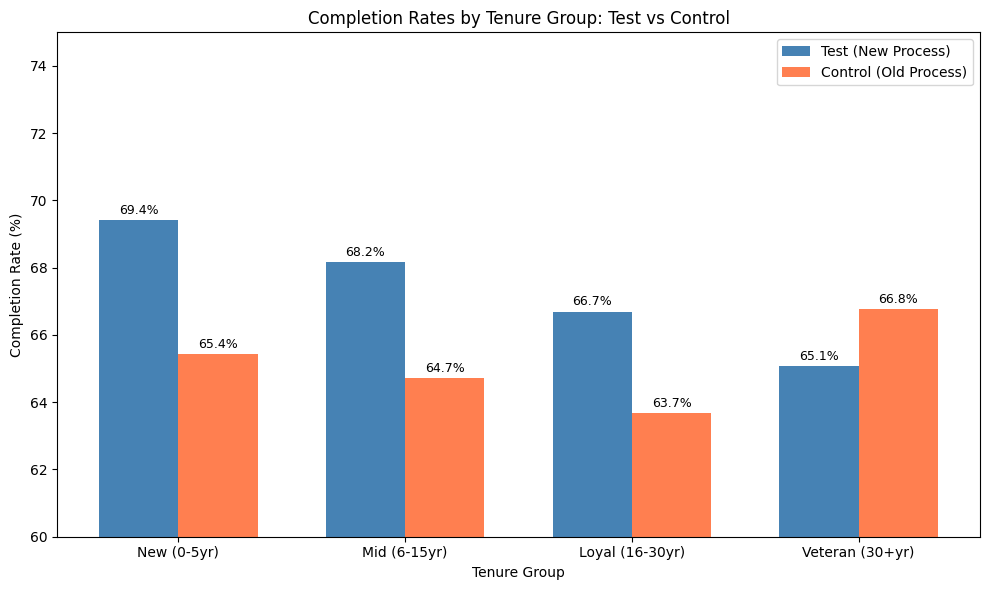

In [73]:
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, test_rates, width, label='Test (New Process)', color='steelblue')
bars2 = ax.bar(x + width/2, control_rates, width, label='Control (Old Process)', color='coral')

ax.set_xlabel('Tenure Group')
ax.set_ylabel('Completion Rate (%)')
ax.set_title('Completion Rates by Tenure Group: Test vs Control')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(60, 75)

# Add percentage labels on top of bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=9)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

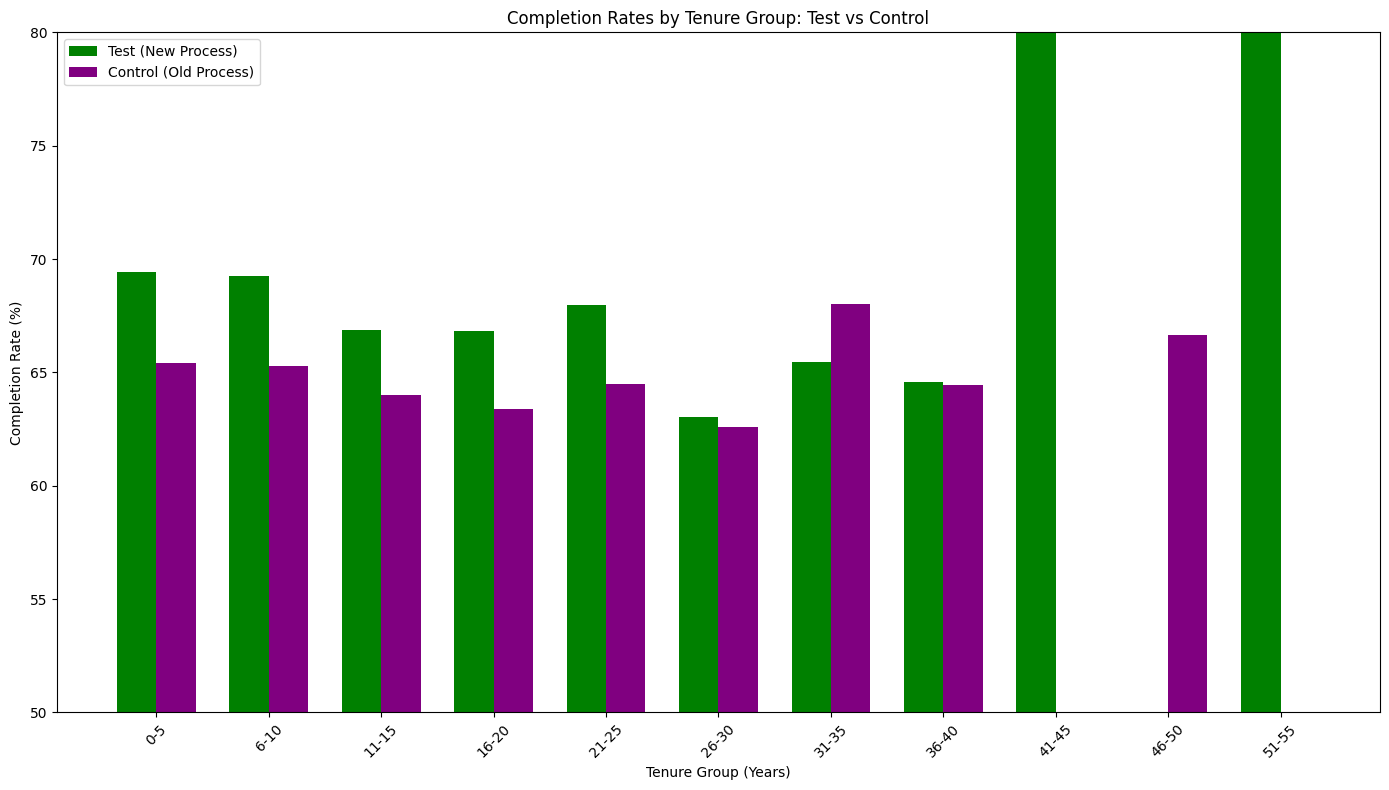

In [77]:
# Create 5-year tenure buckets
bins = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55]
labels = ['0-5', '6-10', '11-15', '16-20', '21-25', '26-30', '31-35', '36-40', '41-45', '46-50', '51-55']

tenure_test['tenure_group'] = pd.cut(tenure_test['clnt_tenure_yr'], bins=bins, labels=labels)
tenure_control['tenure_group'] = pd.cut(tenure_control['clnt_tenure_yr'], bins=bins, labels=labels)

# Calculate completion rate per tenure group
test_rates = tenure_test.groupby('tenure_group')['completed'].mean() * 100
control_rates = tenure_control.groupby('tenure_group')['completed'].mean() * 100

# Plot
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 8))  # wider figure for more groups
bars1 = ax.bar(x - width/2, test_rates, width, label='Test (New Process)', color='green')
bars2 = ax.bar(x + width/2, control_rates, width, label='Control (Old Process)', color='purple')

ax.set_xlabel('Tenure Group (Years)')
ax.set_ylabel('Completion Rate (%)')
ax.set_title('Completion Rates by Tenure Group: Test vs Control')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)  # rotate labels so they don't overlap
ax.legend()
ax.set_ylim(50, 80)

plt.tight_layout()
plt.show()

In [78]:
print("TEST clients per tenure group:")
print(tenure_test['tenure_group'].value_counts().sort_index())

print("\nCONTROL clients per tenure group:")
print(tenure_control['tenure_group'].value_counts().sort_index())

TEST clients per tenure group:
tenure_group
0-5      4743
6-10     8567
11-15    6969
16-20    2998
21-25    2375
26-30     931
31-35     301
36-40      48
41-45       5
46-50      18
51-55       6
Name: count, dtype: int64

CONTROL clients per tenure group:
tenure_group
0-5      3986
6-10     7409
11-15    6140
16-20    2712
21-25    2112
26-30     831
31-35     269
36-40      45
41-45       7
46-50      12
51-55       4
Name: count, dtype: int64


This plot is not reliable because the older tenure groups consist of very few people.

In [79]:
# Recreate bins with 31+ as last group
bins = [0, 5, 10, 15, 20, 25, 30, 55]
labels = ['0-5', '6-10', '11-15', '16-20', '21-25', '26-30', '31+']

tenure_test['tenure_group'] = pd.cut(tenure_test['clnt_tenure_yr'], bins=bins, labels=labels)
tenure_control['tenure_group'] = pd.cut(tenure_control['clnt_tenure_yr'], bins=bins, labels=labels)

test_rates = tenure_test.groupby('tenure_group')['completed'].mean() * 100
control_rates = tenure_control.groupby('tenure_group')['completed'].mean() * 100

print("TEST completion rates:")
print(test_rates)
print("\nCONTROL completion rates:")
print(control_rates)

TEST completion rates:
tenure_group
0-5      69.407548
6-10     69.230769
11-15    66.867556
16-20    66.811207
21-25    67.957895
26-30    63.050483
31+      65.079365
Name: completed, dtype: float64

CONTROL completion rates:
tenure_group
0-5      65.429002
6-10     65.298961
11-15    63.990228
16-20    63.384956
21-25    64.488636
26-30    62.575211
31+      66.765579
Name: completed, dtype: float64


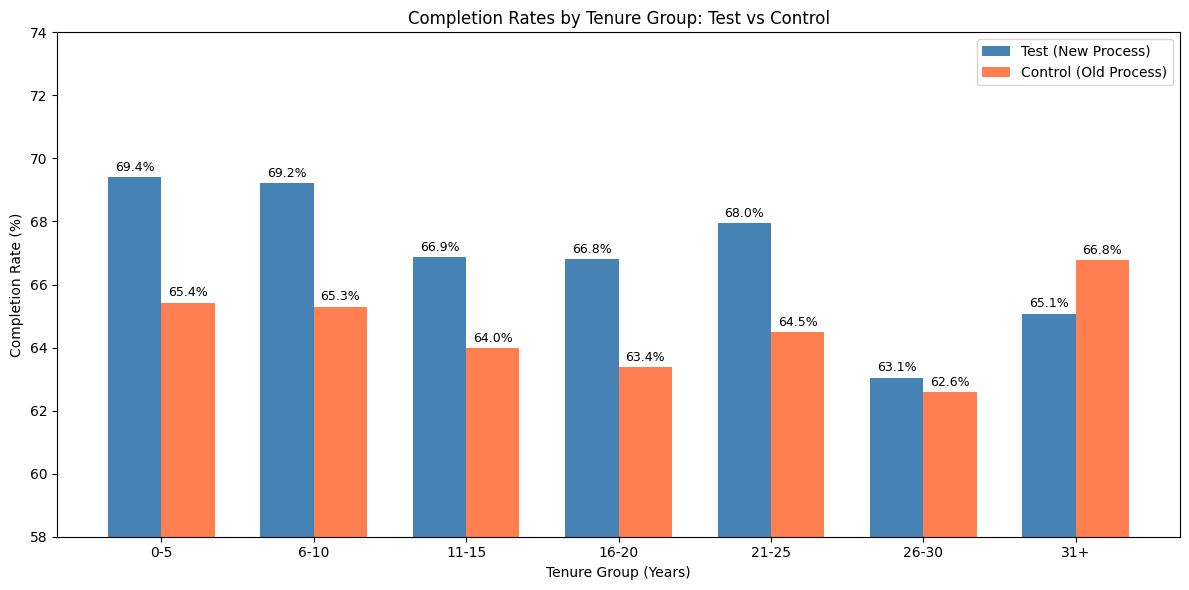

In [80]:
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, test_rates, width, label='Test (New Process)', color='steelblue')
bars2 = ax.bar(x + width/2, control_rates, width, label='Control (Old Process)', color='coral')

ax.set_xlabel('Tenure Group (Years)')
ax.set_ylabel('Completion Rate (%)')
ax.set_title('Completion Rates by Tenure Group: Test vs Control')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(58, 74)

# Add percentage labels on top of bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=9)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Two key conclusions:

The new process works better for most clients — especially newer clients (0-10 years) where the difference is biggest (~4%)
Long tenured clients (31+) actually prefer the old process — these are Vanguard's most loyal clients and they seem to struggle with the new process!